In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.cluster import MeanShift, estimate_bandwidth

In [2]:
address = ""
all_files = glob.glob(address+'images/train_mini3/*.png')
img_row_size = 67
img_col_size = 48
img_size = img_row_size*img_col_size

In [3]:
img_data = []
for i in range(len(all_files)):
    img_color = cv.imread(all_files[i], cv.IMREAD_COLOR)
    img_color = cv.resize(cv.cvtColor(img_color, cv.COLOR_BGR2RGB), (img_col_size, img_row_size))[0:40,15:40,:]
    R = img_color[:, :, 0].astype(int)
    G = img_color[:, :, 1].astype(int)
    B = img_color[:, :, 2].astype(int)
    weighted_image = 1.0 * R - 1.0 * G - 1.0 * B
    weighted_image[weighted_image < 0] = 0

    img_data += [weighted_image]
    #img_gray = cv.imread(all_files[i], cv.IMREAD_GRAYSCALE)
    #img_data += [cv.resize(img_gray, (img_col_size, img_row_size))[0:40,15:40]]

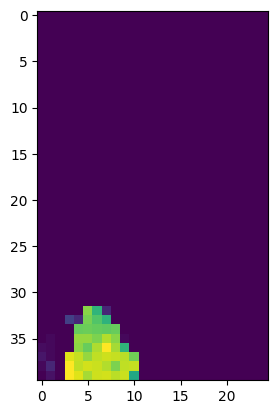

In [4]:
# Key part of the code for forming the rules

eg = 0

X = []
for i in range(len(img_data[eg])):
    for j in range(len(img_data[eg][0])):
        for k in range(int((img_data[eg][i][j])/50)):
            X += [[max(0.001,j+np.random.randn(1)[0]/5),max(0.001,i+np.random.randn(1)[0]/5)]]
X = np.array(X)

plt.imshow(img_data[eg])

Number of estimated clusters: 1
Cluster centers:
 [[ 6.27426027 36.41459552]]


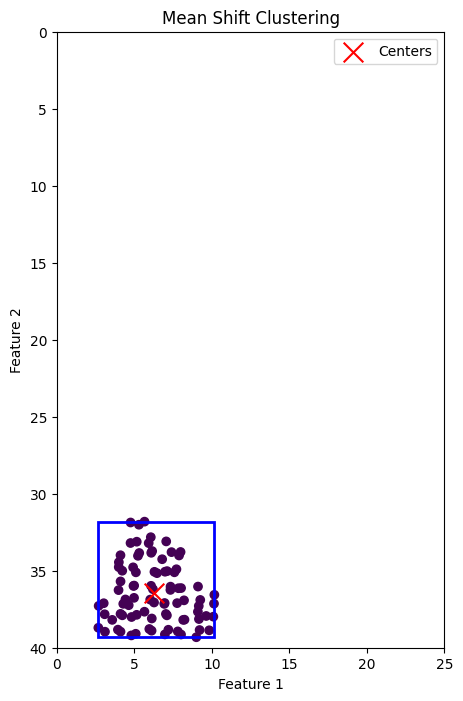

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [2.67, 31.81, 10.16, 39.32, 1.0]


In [5]:
# Bandwidth Estimation

# bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))
bandwidth = 6

# Performing MeanShift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

# Finding the Cluster Centers
cluster_centers = ms.cluster_centers_
labels = ms.labels_

# Normal Cluster Probability
cluster_probabilities = []
total_data_points = len(X)
for label in np.unique(labels):
    cluster_points = X[labels == label]
    num_points = len(cluster_points)
    probability = num_points / total_data_points
    cluster_probabilities.append(probability)
cluster_probabilities = np.array(cluster_probabilities)/np.max(cluster_probabilities)

# Finding the Number of Clusters
n_clusters_ = len(np.unique(labels))

# Print Cluster Centers
print(f"Number of estimated clusters: {n_clusters_}")
print("Cluster centers:\n", cluster_centers)

# Visualization
plt.figure(figsize=(5, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')

# Bounding Boxes
bounding_boxes = []
for label in np.unique(labels):
    cluster_points = X[labels == label]
    min_x, min_y = cluster_points.min(axis=0)
    max_x, max_y = cluster_points.max(axis=0)
    bounding_box = [np.round(min_x,2), np.round(min_y,2), np.round(max_x,2), np.round(max_y,2), np.round(cluster_probabilities[label],2)]
    bounding_boxes.append(bounding_box)
    rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, fill=False, edgecolor='blue', linewidth=2)
    plt.gca().add_patch(rect)

# Graph Settings
plt.xlim([0,25])
plt.ylim([0,40])
plt.title('Mean Shift Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

# Print Bounding Boxes
print("Bounding Boxes [left x, top y, right x, bottom y]:")
for i, bbox in enumerate(bounding_boxes):
    print(f"Cluster {i}: {bbox}")

In [6]:
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter

In [7]:
class KalmanBoxTracker:
    count = 0

    def __init__(self, bbox):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1, 0, 0, 0, 1, 0, 0],
                              [0, 1, 0, 0, 0, 1, 0],
                              [0, 0, 1, 0, 0, 0, 1],
                              [0, 0, 0, 1, 0, 0, 0],
                              [0, 0, 0, 0, 1, 0, 0],
                              [0, 0, 0, 0, 0, 1, 0],
                              [0, 0, 0, 0, 0, 0, 1]])
        self.kf.H = np.array([[1, 0, 0, 0, 0, 0, 0],
                              [0, 1, 0, 0, 0, 0, 0],
                              [0, 0, 1, 0, 0, 0, 0],
                              [0, 0, 0, 1, 0, 0, 0]])
        self.kf.R[2:, 2:] *= 10.
        self.kf.P[4:, 4:] *= 1000.
        self.kf.P *= 10.
        self.kf.Q[-1, -1] *= 0.01
        self.kf.Q[4:, 4:] *= 0.01
        self.kf.x[:4] = self.convert_bbox_to_z(bbox)
        self.time_since_update = 0
        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.history = []
        self.hits = 0
        self.hit_streak = 0
        self.age = 0

    def update(self, bbox):
        self.time_since_update = 0
        self.history = []
        self.hits += 1
        self.hit_streak += 1
        self.kf.update(self.convert_bbox_to_z(bbox))

    def predict(self):
        if (self.kf.x[6] + self.kf.x[2]) <= 0:
            self.kf.x[6] = 0.0
        self.kf.predict()
        self.age += 1
        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1
        self.history.append(self.convert_x_to_bbox(self.kf.x))
        return self.history[-1]

    def get_state(self):
        return self.convert_x_to_bbox(self.kf.x)

    @staticmethod
    def convert_bbox_to_z(bbox):
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = bbox[0] + w / 2.
        y = bbox[1] + h / 2.
        s = w * h
        r = w / float(h)
        return np.array([x, y, s, r]).reshape((4, 1))

    @staticmethod
    def convert_x_to_bbox(x, score=None):
        w = np.sqrt(x[2] * x[3])
        h = x[2] / w
        if score is None:
            return np.array([x[0] - w / 2., x[1] - h / 2., x[0] + w / 2., x[1] + h / 2.]).reshape((1, 4))
        else:
            return np.array([x[0] - w / 2., x[1] - h / 2., x[0] + w / 2., x[1] + h / 2., score]).reshape((1, 5))

In [8]:
def associate_detections_to_trackers(detections, trackers, iou_threshold=0.3):
    if len(trackers) == 0:
        return np.empty((0, 2), dtype=int), np.arange(len(detections)), np.empty((0, 4), dtype=int)

    iou_matrix = np.zeros((len(detections), len(trackers)), dtype=np.float32)

    for d, det in enumerate(detections):
        for t, trk in enumerate(trackers):
            iou_matrix[d, t] = iou(det, trk)

    matched_indices = linear_sum_assignment(-iou_matrix)

    matched_indices = np.asarray(matched_indices)
    matched_indices = np.transpose(matched_indices)

    unmatched_detections = []
    for d, det in enumerate(detections):
        if d not in matched_indices[:, 0]:
            unmatched_detections.append(d)
    unmatched_trackers = []
    for t, trk in enumerate(trackers):
        if t not in matched_indices[:, 1]:
            unmatched_trackers.append(t)

    matches = []
    for m in matched_indices:
        if iou_matrix[m[0], m[1]] < iou_threshold:
            unmatched_detections.append(m[0])
            unmatched_trackers.append(m[1])
        else:
            matches.append(m.reshape(1, 2))
    if len(matches) == 0:
        matches = np.empty((0, 2), dtype=int)
    else:
        matches = np.concatenate(matches, axis=0)

    return matches, np.array(unmatched_detections), np.array(unmatched_trackers)

In [9]:
def iou(bb_test, bb_gt):
    xx1 = np.maximum(bb_test[0], bb_gt[0])
    yy1 = np.maximum(bb_test[1], bb_gt[1])
    xx2 = np.minimum(bb_test[2], bb_gt[2])
    yy2 = np.minimum(bb_test[3], bb_gt[3])
    w = np.maximum(0., xx2 - xx1)
    h = np.maximum(0., yy2 - yy1)
    wh = w * h
    o = wh / ((bb_test[2] - bb_test[0]) * (bb_test[3] - bb_test[1])
              + (bb_gt[2] - bb_gt[0]) * (bb_gt[3] - bb_gt[1]) - wh)
    return o

In [10]:
class Sort:
    def __init__(self, max_age=1, min_hits=3, iou_threshold=0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0

    def update(self, dets=np.empty((0, 5))):
        self.frame_count += 1
        
        # Filter detections based on confidence threshold
        confidence_threshold = 0.1
        dets = dets[dets[:, 4] >= confidence_threshold]

        trks = np.zeros((len(self.trackers), 5))
        to_del = []
        ret = []
        for t, trk in enumerate(self.trackers):
            pos = trk.predict()[0]
            trks[t, :] = [pos[0], pos[1], pos[2], pos[3], 0]
            if np.any(np.isnan(pos)):
                to_del.append(t)
        trks = np.ma.compress_rows(np.ma.masked_invalid(trks))
        for t in reversed(to_del):
            self.trackers.pop(t)
        matched, unmatched_dets, unmatched_trks = associate_detections_to_trackers(dets, trks, self.iou_threshold)
        for t, trk in enumerate(self.trackers):
            if t not in unmatched_trks:
                d = matched[np.where(matched[:, 1] == t)[0], 0]
                trk.update(dets[d, :][0])
        for i in unmatched_dets:
            trk = KalmanBoxTracker(dets[i, :])
            self.trackers.append(trk)
        i = len(self.trackers)
        for trk in reversed(self.trackers):
            d = trk.get_state()[0]
            if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                ret.append(np.concatenate((d, [trk.id + 1])).reshape(1, -1))  # Append with ID
            i -= 1
            if trk.time_since_update > self.max_age:
                self.trackers.pop(i)
        if len(ret) > 0:
            return np.concatenate(ret)
        return np.empty((0, 5))

In [11]:
sort = Sort()
detection = [np.array(bounding_boxes)]
trackers = sort.update(detection[0])
print(trackers)

[[ 2.67 31.81 10.16 39.32  1.  ]]


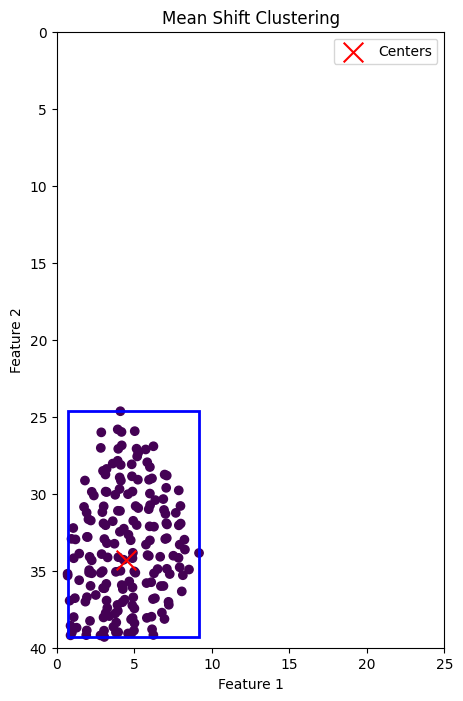

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.69, 24.64, 9.17, 39.3, 1.0]
[[ 0.69 24.64  9.17 39.3   2.  ]]


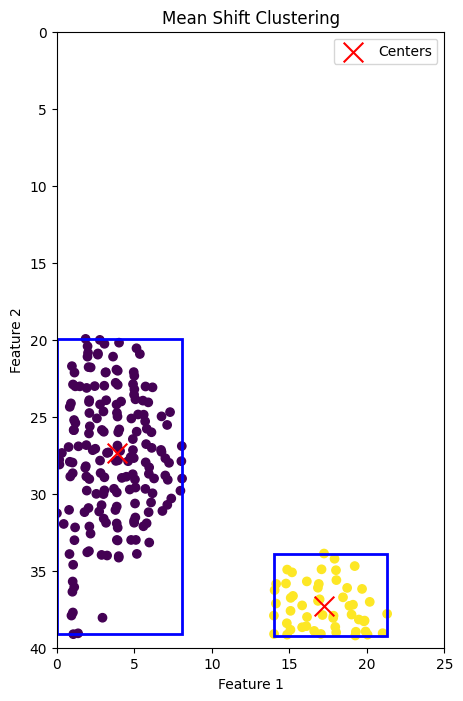

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.0, 19.95, 8.08, 39.12, 1.0]
Cluster 1: [14.0, 33.88, 21.31, 39.21, 0.29]
[[14.   33.88 21.31 39.21  4.  ]
 [ 0.   19.95  8.08 39.12  3.  ]]


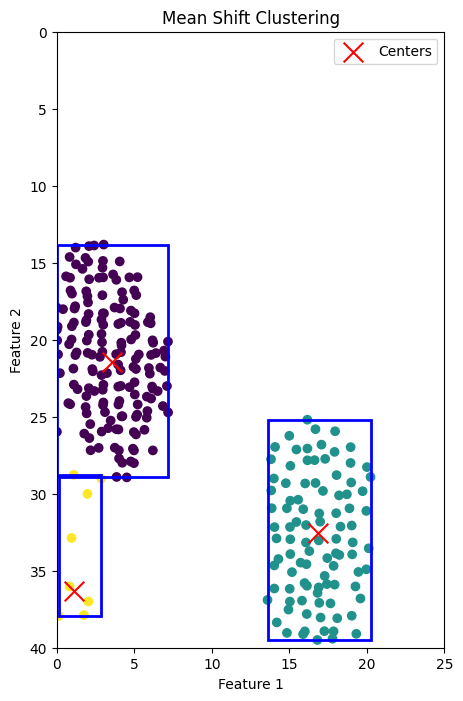

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.0, 13.82, 7.17, 28.94, 1.0]
Cluster 1: [13.59, 25.19, 20.23, 39.5, 0.6]
Cluster 2: [0.11, 28.78, 2.87, 37.94, 0.05]
[[13.59 25.19 20.23 39.5   6.  ]
 [ 0.   13.82  7.17 28.94  5.  ]]


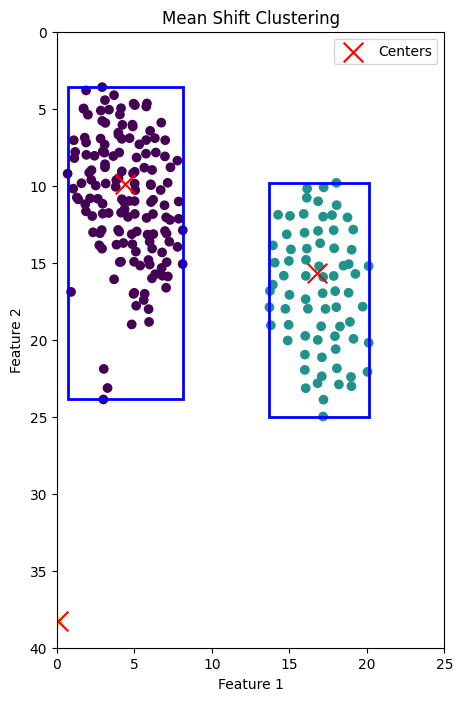

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.69, 3.6, 8.12, 23.88, 1.0]
Cluster 1: [13.71, 9.81, 20.11, 24.99, 0.49]
Cluster 2: [0.04, 38.29, 0.04, 38.29, 0.01]
[[13.71  9.81 20.11 24.99  8.  ]
 [ 0.69  3.6   8.12 23.88  7.  ]]


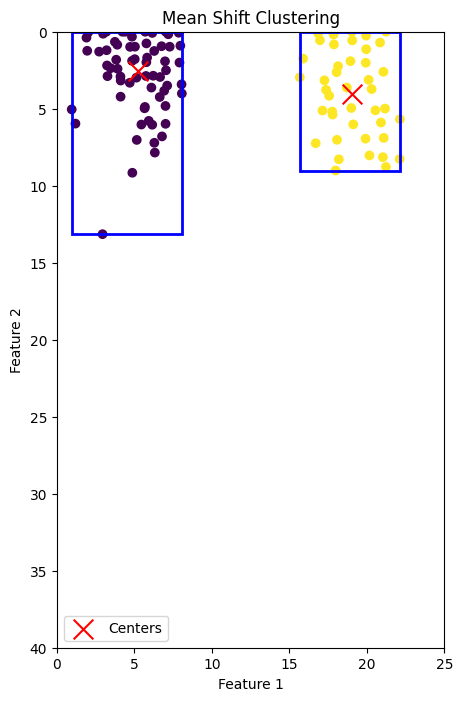

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.96, 0.0, 8.06, 13.15, 1.0]
Cluster 1: [15.67, 0.0, 22.13, 9.01, 0.64]
[[15.67  0.   22.13  9.01 10.  ]
 [ 0.96  0.    8.06 13.15  9.  ]]


In [12]:
for eg in range(1,len(all_files)):
    X = []
    for i in range(len(img_data[eg])):
        for j in range(len(img_data[eg][0])):
            for k in range(int((img_data[eg][i][j])/50)):
                X += [[max(0.001,j+np.random.randn(1)[0]/5),max(0.001,i+np.random.randn(1)[0]/5)]]
    X = np.array(X)
    
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(X)
    
    # Finding the Cluster Centers
    cluster_centers = ms.cluster_centers_
    labels = ms.labels_
    
    # Normal Cluster Probability
    cluster_probabilities = []
    total_data_points = len(X)
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        num_points = len(cluster_points)
        probability = num_points / total_data_points
        cluster_probabilities.append(probability)
    cluster_probabilities = np.array(cluster_probabilities)/np.max(cluster_probabilities)
    
    # Finding the Number of Clusters
    n_clusters_ = len(np.unique(labels))
    
    # Visualization
    plt.figure(figsize=(5, 8))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
    plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')
    
    # Bounding Boxes
    bounding_boxes = []
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        min_x, min_y = cluster_points.min(axis=0)
        max_x, max_y = cluster_points.max(axis=0)
        bounding_box = [np.round(min_x,2), np.round(min_y,2), np.round(max_x,2), np.round(max_y,2), np.round(cluster_probabilities[label],2)]
        bounding_boxes.append(bounding_box)
        rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, fill=False, edgecolor='blue', linewidth=2)
        plt.gca().add_patch(rect)
    
    # Graph Settings
    plt.xlim([0,25])
    plt.ylim([0,40])
    plt.title('Mean Shift Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()
    
    # Print Bounding Boxes
    print("Bounding Boxes [left x, top y, right x, bottom y]:")
    for i, bbox in enumerate(bounding_boxes):
        print(f"Cluster {i}: {bbox}")
    
    sort = Sort()
    detection += [np.array(bounding_boxes)]
    trackers = sort.update(detection[-1])
    print(trackers)